In [18]:
df = pd.read_csv("Sentiment dataset.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text', 'clean_text']].head()

,Text,clean_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


In [20]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['predicted_sentiment'] = df['clean_text'].apply(get_sentiment)
df[['Text', 'Sentiment', 'predicted_sentiment']].head(10)

,Text,Sentiment,predicted_sentiment
0,Enjoying a beautiful day at the park! ...,Positive,Positive
1,Traffic was terrible this morning. ...,Negative,Negative
2,Just finished an amazing workout! 💪 ...,Positive,Positive
3,Excited about the upcoming weekend getaway! ...,Positive,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral,Positive
5,Feeling grateful for the little things in lif...,Positive,Negative
6,Rainy days call for cozy blankets and hot coc...,Positive,Positive
7,The new movie release is a must-watch! ...,Positive,Positive
8,Political discussions heating up on the timel...,Negative,Neutral
9,Missing summer vibes and beach days. ...,Neutral,Negative


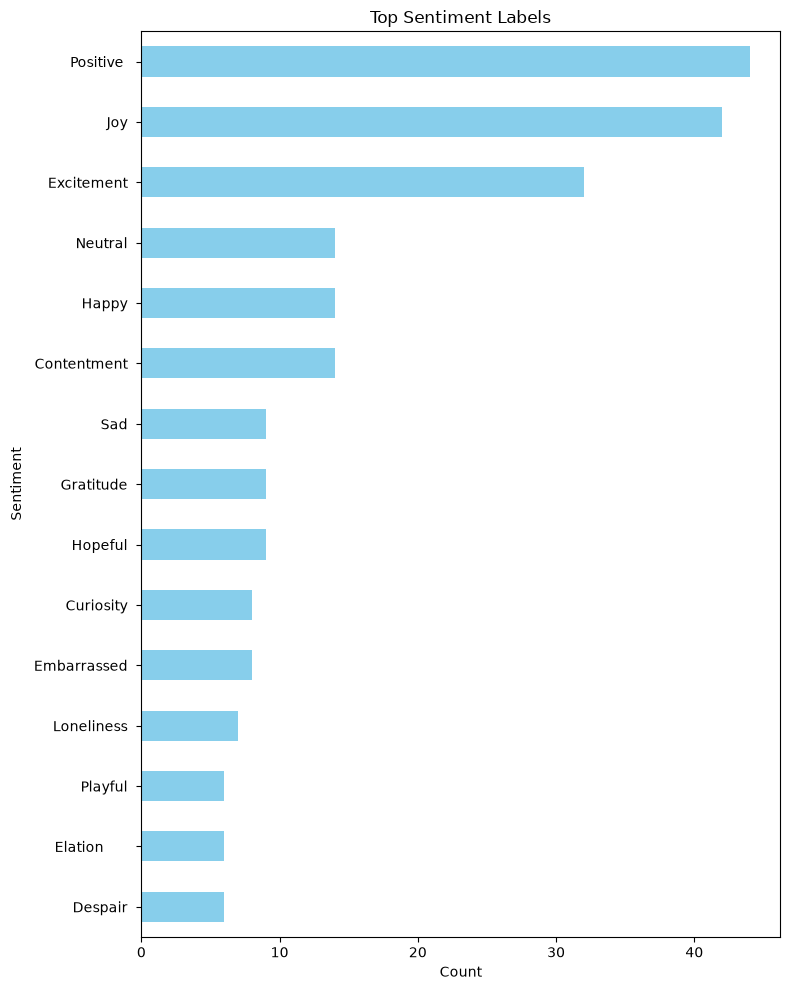

In [21]:
plt.figure(figsize=(8,10))
df['Sentiment'].value_counts().head(15).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top Sentiment Labels')
plt.xlabel('Count')
plt.ylabel('Sentiment')
plt.tight_layout()
plt.show()

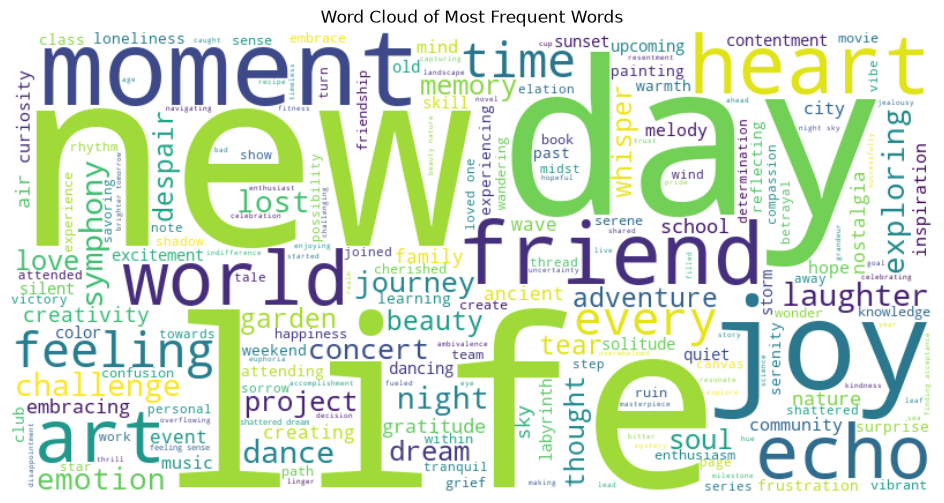

In [22]:
all_words = ' '.join(df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words')
plt.show()

In [23]:
df['Sentiment'].unique()
df['Sentiment'].nunique()

279

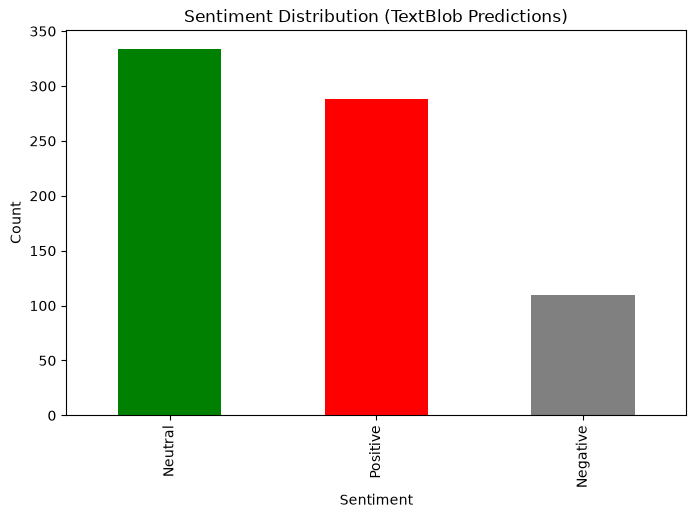

In [24]:
plt.figure(figsize=(8, 5))
df['predicted_sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution (TextBlob Predictions)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Conclusion:
- The text was cleaned using lowercasing, punctuation removal, stopword removal, and lemmatization.
- TextBlob was used to classify each text as Positive, Negative, or Neutral.
- The word cloud highlights the most frequent words in the dataset.
- The predicted sentiment distribution shows the overall tone of the corpus.